In [2]:
import pandas as pd
import sqlite3
# Charger les fichiers clean
clients = pd.read_csv('data/clean/client_clean.csv')
commandes = pd.read_csv('data/clean/commande_clean.csv')
produits = pd.read_csv('data/clean/produit_clean.csv')

# Vérification rapide
print('clients:', clients.shape)
print('commandes:', commandes.shape)
print('produits:', produits.shape)



clients: (188, 7)
commandes: (1015, 9)
produits: (50, 6)


In [3]:
commandes.head()

,id,client_id,produit_id,quantité,total_eur,status,date_commande,revenue_eur,revenue_usd
0,1,179,47,5,2211941.59,pending,2025-12-23,2211941.59,2388896.92
1,2,3,18,1,226800.98,completed,2025-10-08,226800.98,244945.06
2,3,20,39,2,2143342.73,refunded,2025-09-22,2143342.73,2314810.15
3,4,16,38,3,380631.45,completed,2025-07-05,380631.45,411081.97
4,5,95,37,5,2249981.41,completed,2025-08-06,2249981.41,2429979.92


In [4]:
revenue_totale=commandes['total_eur'].sum()
revenue_totale

np.float64(1577024157.8899999)

In [5]:
panier_moyen=round(commandes.groupby('id')['total_eur'].sum().mean(),2)
panier_moyen

np.float64(1553718.38)

In [6]:
clients.head()

,id,nom,email,city,pays,date_inscription,categorie_client
0,1,Marc Lacroix-Seguin,marc.seguin5862@shopflow.com,La Plata,Argentine,2025-08-13,nouveau
1,2,Roger Perrot,roger.perrot9726@shopflow.com,Los Angeles,Etats-Unis,2026-02-27,fidele
2,3,Simone Marin du Clément,simone.clement8102@shopflow.com,Kyoto,Japon,2025-08-19,fidele
3,4,Léon Imbert,leon.imbert2512@shopflow.com,Buenos Aires,Argentine,2025-08-13,fidele
4,5,Bernard Lopez-Perrot,bernard.perrot3663@shopflow.com,Tanger,Maroc,2025-06-13,fidele


In [7]:
# Clients actifs = clients connus avec au moins une commande complétée
clients_actifs = (
    commandes.loc[commandes['status'].eq('completed')]
    .merge(clients[['id']], left_on='client_id', right_on='id', how='inner')['client_id']
    .nunique()
 )
clients_actifs


183

In [8]:
produits.head()

,id,categorie,name,prix_eur,stock,prix_usd
0,1,Clothing,Basic T-Shirt,379.12,229,409.45
1,2,Home,Storage Box,345.57,134,373.22
2,3,Electronics,Bluetooth Speaker,373.42,149,403.29
3,4,Sports,Fitness Band,291.71,336,315.05
4,5,Sports,Water Bottle,47.92,412,51.75


In [9]:
# 1. Jointure : orders + products
df = commandes.merge(produits, left_on='produit_id', right_on='id', suffixes=('', '_produits'))

# 2. Grouper par nom de produit + sommer le revenue
top_produits = round(df.groupby('name')['total_eur'].sum(),2)

# 3. Trier + garder les 10 premiers
top_produits = top_produits.sort_values(ascending=False).head(10)
top_produits

name
Dumbbells Set             2.365102e+08
Data Analysis Handbook    1.837127e+08
Fitness Band              1.019104e+08
Shampoo                   9.765481e+07
Basic T-Shirt             9.304330e+07
Coffee Mug Set            9.189607e+07
Running Shoes             8.251570e+07
Bluetooth Speaker         7.219826e+07
Body Lotion               6.369868e+07
Marketing Strategy        6.029330e+07
Name: total_eur, dtype: float64

In [10]:

rev_par_categorie = (
    commandes[commandes['status'] == 'completed']
    .merge(produits[['id', 'categorie']], left_on='produit_id', right_on='id', how='left')
    .groupby('categorie')['total_eur']
    .sum()
    .round(2)
    .sort_values(ascending=False)
 )
rev_par_categorie

categorie
Sports         3.250332e+08
Books          1.915976e+08
Electronics    1.766083e+08
Home           1.537079e+08
Beauty         1.396088e+08
Clothing       1.374960e+08
Name: total_eur, dtype: float64

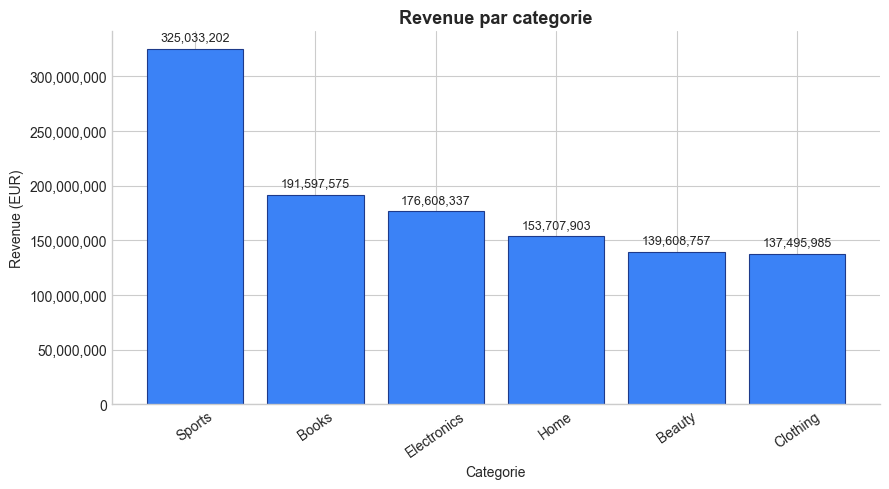

In [11]:
# Graphique KPI 1 : Revenue par categorie
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(9, 5))
barres = ax.bar(
    rev_par_categorie.index,
    rev_par_categorie.values,
    color='#3B82F6',
    edgecolor='#1E3A8A',
    linewidth=0.8
 )

ax.set_title('Revenue par categorie', fontsize=13, weight='bold')
ax.set_xlabel('Categorie')
ax.set_ylabel('Revenue (EUR)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for b in barres:
    h = b.get_height()
    ax.annotate(
        f'{h:,.0f}',
        (b.get_x() + b.get_width() / 2, h),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [12]:

cmd_completed = commandes[commandes['status'] == 'completed'].copy()
cmd_completed['mois'] = pd.to_datetime(
    cmd_completed['date_commande'], errors='coerce'
 ).dt.to_period('M').astype(str)

rev_par_mois = (
    cmd_completed.groupby('mois')['total_eur']
    .sum()
    .round(2)
    .sort_index()
 )
rev_par_mois

mois
2025-07    2.195998e+08
2025-08    1.998962e+08
2025-09    2.029296e+08
2025-10    1.666169e+08
2025-11    1.549215e+08
2025-12    1.800877e+08
Name: total_eur, dtype: float64

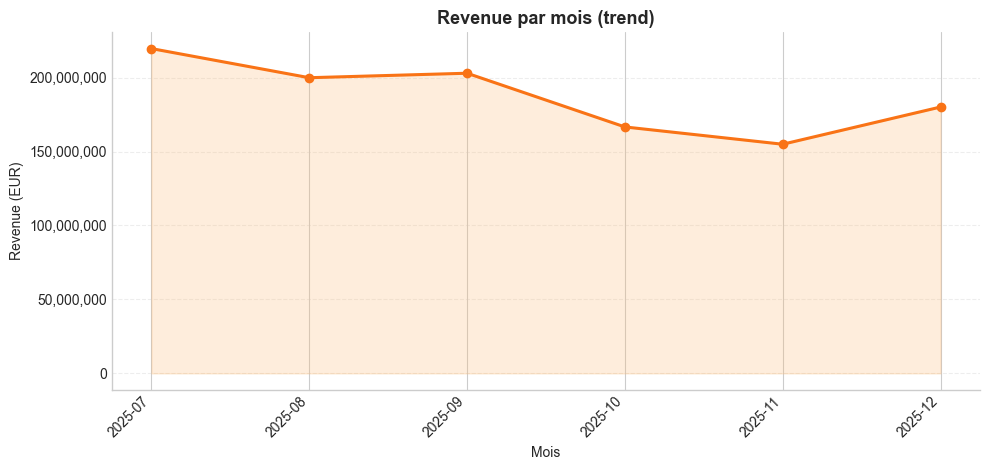

In [13]:
# Graphique KPI 2 : Revenue par mois
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    rev_par_mois.index,
    rev_par_mois.values,
    marker='o',
    markersize=6,
    linewidth=2.2,
    color='#F97316'
 )

ax.fill_between(
    rev_par_mois.index,
    rev_par_mois.values,
    color='#FDBA74',
    alpha=0.25
 )

ax.set_title('Revenue par mois (trend)', fontsize=13, weight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Revenue (EUR)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [14]:

top_10_clients = (
    commandes[commandes['status'] == 'completed']
    .merge(clients[['id', 'nom']], left_on='client_id', right_on='id', how='left')
    .groupby(['client_id', 'nom'])['total_eur']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .head(10)
 )
top_10_clients

client_id  nom                         
101        Joséphine Colin                 16226778.73
45         Yves Buisson                    14711528.65
18         Jeannine Cousin de Pascal       13563668.60
43         Jean Pages                      13524535.31
154        Bertrand-Jérôme Millet          13337486.45
69         Théophile Barthelemy            13215932.79
148        Claude Guichard                 12752757.15
141        Astrid Fernandez                12705060.43
2          Roger Perrot                    11280601.82
181        Élisabeth Delahaye du Dubois    11105394.19
Name: total_eur, dtype: float64

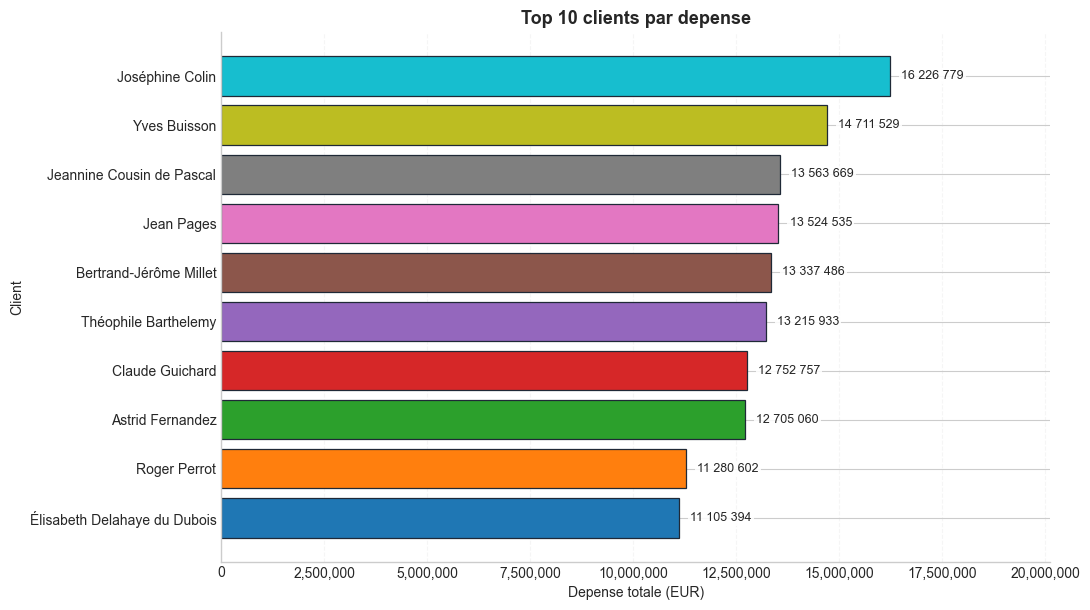

In [15]:
# Graphique KPI 3 : Top 10 clients par depense
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

top_10_clients_df = top_10_clients.reset_index().sort_values('total_eur')
top_10_clients_df['nom_affiche'] = top_10_clients_df['nom'].fillna(
    top_10_clients_df['client_id'].astype(str)
 )

# Une couleur differente par client (plus contrastee)
couleurs = plt.cm.tab10(np.linspace(0, 1, len(top_10_clients_df)))

fig, ax = plt.subplots(figsize=(11, 6.2))
barres = ax.barh(
    top_10_clients_df['nom_affiche'],
    top_10_clients_df['total_eur'],
    color=couleurs,
    edgecolor='#1f2937',
    linewidth=0.9
 )

ax.set_title('Top 10 clients par depense', fontsize=13, weight='bold')
ax.set_xlabel('Depense totale (EUR)')
ax.set_ylabel('Client')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.18)

# Ajouter de la place a droite pour les etiquettes
max_value = top_10_clients_df['total_eur'].max()
ax.set_xlim(0, max_value * 1.24)

for b in barres:
    w = b.get_width()
    ax.annotate(
        f'{w:,.0f}'.replace(',', ' '),
        (w, b.get_y() + b.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(8, 0),
        textcoords='offset points',
        clip_on=False,
        bbox=dict(facecolor='white', alpha=0.88, edgecolor='none', pad=1.5)
    )

plt.tight_layout()
plt.show()